## CLIP-Style Multimodal Urgency Classification
We implement a binary urgency classification model on the [EgoBlind](https://arxiv.org/abs/2503.08221) dataset using a [CLIP](https://arxiv.org/abs/2103.00020)-style architecture with lightweight fusion. The goal is to predict urgency at the question-level by modelling localised visual contxt around the queried timepoint.

**Pipeline**:
- For each question timestamp $t_q$, sample $K$ frames from temporal window centred at $t_q$
- Encode sampled frames with pretrained CLIP image encoder
- Mean/attention-pool frame embeddings to obtain a question-conditioned video representation
- Encode associated question using CLIP text encoder
- Concatenate video and text embeddings
- Apply a lightweight 2-layer MLP to obtain a binary logit
- Train under a binary cross-entropy loss
- Evaluate with accuracy, precision, recall, F1 and AUC

**Authors**: Julia Kim, Xander Backus

## Set Up and Configure



In [1]:
import sys
print(sys.executable)

/home/julia225/miniconda3/envs/clip_env/bin/python


In [31]:
import sys
!{sys.executable} -m pip install matplotlib

  Using cached matplotlib-3.10.8-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (6.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.7 MB)
Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (325 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (4.9 MB)
Using cached kiwisolver-1.4.9-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl

In [32]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve
from tqdm import tqdm
from decord import VideoReader, cpu
import open_clip
from PIL import Image
import zipfile
import shutil
import glob
from pathlib import Path

In [3]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))

2.7.1+cu118
11.8
NVIDIA L40S


In [4]:
# --------------------------------------------------
# CONFIG 
# --------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
criterion = torch.nn.BCEWithLogitsLoss()
os.environ["FFMPEG_LOG_LEVEL"] = "quiet"

K_FRAMES = 4
WINDOW_SEC = 2
BATCH_SIZE = 2
LR = 1e-4
NUM_EPOCHS = 5
CLIP_MODEL = "ViT-B-32"
FREEZE_CLIP = True
VAL_SPLIT = 0.2

In [5]:
# --------------------------------------------------
# PATHS  
# --------------------------------------------------
# Train 
ZIP_FOLDER = "train/Videos"
VIDEO_ROOT = "train/extracted_videos"
MARKER_FILE = Path(VIDEO_ROOT) / ".extracted_done"
CHECKPOINT_DIR = "checkpoints"
FINAL_MODEL_PATH = "final_model.pt"

# Test 
ZIP_FOLDER_TEST = "test/Videos"
VIDEO_ROOT_TEST = "test/extracted_videos"
MARKER_FILE_TEST = Path(VIDEO_ROOT_TEST) / ".extracted_done"

## Load and Clean Dataset

#### Text and Labels

In [7]:
!wget https://raw.githubusercontent.com/juliavekim/EgoBlind-RA/main/train_labeled.csv -O train_labeled.csv

--2026-03-06 14:23:10--  https://raw.githubusercontent.com/juliavekim/EgoBlind-RA/main/train_labeled.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 433721 (424K) [text/plain]
Saving to: ‘train_labeled.csv’

train_labeled.csv   100%[===================>] 423.56K  --.-KB/s    in 0.04s   

2026-03-06 14:23:11 (9.59 MB/s) - ‘train_labeled.csv’ saved [433721/433721]



In [53]:
!wget https://raw.githubusercontent.com/juliavekim/EgoBlind-RA/refs/heads/main/test_labeled.csv -O test_labeled.csv

--2026-03-06 16:14:40--  https://raw.githubusercontent.com/juliavekim/EgoBlind-RA/refs/heads/main/test_labeled.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 295844 (289K) [text/plain]
Saving to: ‘test_labeled.csv’

test_labeled.csv    100%[===================>] 288.91K  --.-KB/s    in 0.04s   

2026-03-06 16:14:41 (7.26 MB/s) - ‘test_labeled.csv’ saved [295844/295844]



In [8]:
def load_and_clean_csv(csv_path):
    """
    Load and preprocess the labeled training CSV for the video–question dataset.

    This function reads the CSV file, cleans column formatting, extracts the
    numeric video identifier from the `question_id`, converts urgency labels
    into binary values, and determines the dataset split in which each video
    resides.
    """ 
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    # Extract numeric video id from question_id
    df["video_name"] = df["question_id"].apply(lambda x: x.split("_")[1])

    df["label"] = df["urgency"].map({"urgent": 1, "not_urgent": 0})

    df = df.rename(columns={"start-time/s": "timestamp"})
    df = df.dropna(subset=["timestamp", "label"])

    # Determine which split folder the video lives in
    df["video_name"] = df["video_name"].astype(int)
    df["split"] = df["video_name"].apply(lambda x: f"split_{x // 10000}")
    df["video_name"] = df["video_name"].apply(lambda x: f"{x:05d}")

    return df[["video_name", "split", "question", "timestamp", "label"]]

# Load and clean train CSV
df = load_and_clean_csv("train_labeled.csv")

# Load and clean test CSV
df_test = load_and_clean_csv("test_labeled.csv")

In [9]:
print("TRAIN — First 5 rows:")
print(df.head())

print("\nTRAIN — Class distribution:")
print(df["label"].value_counts())

print("\nTEST — First 5 rows:")
print(df_test.head())

print("\nTEST — Class distribution:")
print(df_test["label"].value_counts())

TRAIN — First 5 rows:
  video_name    split                                           question  \
0      00000  split_0     Is the driver looking at me or facing forward?   
1      00000  split_0               Is everything secure inside the car?   
2      00000  split_0                How do I lower or raise the window?   
3      00000  split_0  Which direction will I need to move to exit th...   
4      00000  split_0                      How do I adjust the seatbelt?   

   timestamp  label  
0      40.98    0.0  
1      54.00    0.0  
2      22.98    0.0  
3      46.98    1.0  
4       6.99    1.0  

TRAIN — Class distribution:
label
1.0    1474
0.0    1270
Name: count, dtype: int64

TEST — First 5 rows:
  video_name    split                                           question  \
0      00923  split_0                          Am I facing the gate now?   
1      00925  split_0                 Is the staff or conductor near me?   
2      00926  split_0  What other services can I acces

#### Videos

In [ ]:
# !pip install gdown
## Extract all videos from the train set from https://drive.google.com/drive/folders/1zW8waLCS_8Ay8kOWpCsvF77IeIG9TzOq using the following syntax
# !python -m gdown -O train/Videos/split_7.zip https://drive.google.com/uc?id=1zgJOKP1Uz24LVaZesH0h3xYz5GvJ1YBe
## Extract all videos from the test set from https://drive.google.com/drive/folders/1Kl6I_prWGbevk-wNi1KQ-1FvNIJm7X33 in a similar way 

In [11]:
# --------------------------------------------------
# Video extraction and indexing utilities
# --------------------------------------------------
def extract_videos(zip_folder: str, output_dir: str, marker_file: Path) -> None:
    """
    Extract all video zip files into a target directory.

    Extraction runs only once. A marker file is created after the first
    successful extraction so subsequent runs skip the process.
    """
    os.makedirs(output_dir, exist_ok=True)

    if marker_file.exists():
        print("Videos already extracted. Skipping.")
        return

    zip_files = sorted(f for f in os.listdir(zip_folder) if f.endswith(".zip"))

    for file in zip_files:
        zip_path = os.path.join(zip_folder, file)
        print(f"Extracting: {file}")

        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(output_dir)

    marker_file.touch()
    print("Extraction complete.")

def build_video_index(video_root: str) -> dict:
    """
    Scan the video directory and build a mapping from video ID to file path.
    """
    videos = list(Path(video_root).rglob("*.mp4"))
    print("Videos on disk:", len(videos))

    video_index = {v.stem: str(v) for v in videos}
    print("Indexed videos:", len(video_index))

    return video_index

# Run extraction for train and test
extract_videos(ZIP_FOLDER, VIDEO_ROOT, MARKER_FILE)
extract_videos(ZIP_FOLDER_TEST, VIDEO_ROOT_TEST, MARKER_FILE_TEST)

# Build index for train and test
video_index = build_video_index(VIDEO_ROOT)
video_index_test = build_video_index(VIDEO_ROOT_TEST)
df_test = df_test[df_test["video_name"].isin(video_index_test)]

Videos already extracted. Skipping.
Videos already extracted. Skipping.
Videos on disk: 675
Indexed videos: 675
Videos on disk: 713
Indexed videos: 713


In [13]:
## Remove corrupted vids 
#!rm train/extracted_videos/split_9/00921.mp4
#!rm train/extracted_videos/split_1/00094.mp4
#!rm test/extracted_videos/split_5/01306.mp4

## Perform Frame Sampling

In [14]:
# --------------------------------------------------
# Video frame sampling utility
# --------------------------------------------------
def sample_frames(video_path, timestamp, K=K_FRAMES, window_sec=WINDOW_SEC):
    """
    Sample K frames from a video centered around a given timestamp.

    Frames are uniformly sampled from a temporal window around the event
    timestamp. This allows the model to capture context before and after
    the event.
    """
    # Open video using decord for efficient frame decoding
    vr = VideoReader(video_path, ctx=cpu(0))

    # Frames per second of the video
    fps = vr.get_avg_fps()

    # Convert timestamp (seconds) to frame index
    center_frame = int(timestamp * fps)

    # Define temporal sampling window
    half_window = int(window_sec * fps)

    start = max(0, center_frame - half_window)
    end = min(len(vr) - 1, center_frame + half_window)

    # Uniformly sample K frames within the window
    indices = np.linspace(start, end, K, dtype=int)

    # Retrieve frames from the video
    frames = vr.get_batch(indices).asnumpy()

    return frames

## Define Model Architecture

In [15]:
# --------------------------------------------------
# CLIP-based multimodal urgency classification model
# --------------------------------------------------
class EgoBlindUrgencyModel(nn.Module):
    """
    CLIP-based multimodal binary urgency classifier.
    Encodes sampled video frames and question text, fuses embeddings,
    and predicts a single urgency logit.
    """

    def __init__(self, clip_model_name="ViT-B-32", freeze_clip=True):
        super().__init__()

        # Load pretrained CLIP backbone
        self.clip_model, self.preprocess, _ = open_clip.create_model_and_transforms(
            clip_model_name, pretrained="openai"
        )

        # Tokenizer for text inputs
        self.tokenizer = open_clip.get_tokenizer(clip_model_name)

        # Embedding dimension (typically 512 for ViT-B/32)
        embed_dim = self.clip_model.text_projection.shape[1]

        # Lightweight fusion head
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim * 2, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 1)
        )

        # Optionally freeze CLIP backbone
        if freeze_clip:
            for param in self.clip_model.parameters():
                param.requires_grad = False

    def forward(self, frames, text_tokens):
        """
        frames: (B, K, 3, 224, 224)
        text_tokens: (B, seq_len)
        returns: (B,) logits
        """
        B, K, C, H, W = frames.shape

        # Flatten temporal dimension
        frames = frames.view(B * K, C, H, W)

        # Encode frames
        frame_embeds = self.clip_model.encode_image(frames)
        frame_embeds = frame_embeds.view(B, K, -1)

        # Mean temporal pooling
        video_embed = frame_embeds.mean(dim=1)

        # Encode text
        text_embed = self.clip_model.encode_text(text_tokens)

        # Fuse modalities
        fused = torch.cat([video_embed, text_embed], dim=-1)

        logits = self.classifier(fused)

        return logits.squeeze(-1)

## Construct Multimodal Dataset

In [16]:
# --------------------------------------------------
# EgoBlind dataset (video–text multimodal samples)
# --------------------------------------------------
class EgoBlindDataset(Dataset):
    """
    PyTorch Dataset for EgoBlind multimodal video–text classification.

    Each sample consists of:
        - A sequence of K video frames sampled around a timestamp.
        - A tokenized natural language question.
        - A binary label indicating whether the question is answerable.

    The dataset retrieves frames from videos using a pre-built video index
    that maps video names to file paths. If a video is missing or decoding
    fails, blank frames are substituted or the next valid sample is returned.

    Text questions are tokenized once during initialization for efficiency.
    """

    def __init__(self, df, video_index, preprocess, tokenizer, K_FRAMES, WINDOW_SEC):
        self.df = df.reset_index(drop=True)
        self.video_index = video_index
        self.preprocess = preprocess
        self.K = K_FRAMES
        self.window = WINDOW_SEC

        # Pre-tokenize once
        self.text_tokens = torch.tensor(
            tokenizer(self.df["question"].tolist()),
            dtype=torch.long
        )

    def __len__(self):
        return len(self.df)

    def _blank_frames(self):
        return np.zeros((self.K, 224, 224, 3), dtype=np.uint8)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]
        video_name = str(row["video_name"])

        if video_name not in self.video_index:
            print(f"Missing video: {video_name}")
            frames = self._blank_frames()

        else:
            video_path = self.video_index[video_name]

            try:
                frames = sample_frames(video_path, row["timestamp"], K=self.K)
            except Exception:
                print(f"Video decode error: {video_path}")
                return self.__getitem__((idx + 1) % len(self.df))

        if not isinstance(frames, (list, np.ndarray)) or len(frames) != self.K:
            frames = self._blank_frames()

        frames = [self.preprocess(Image.fromarray(frame)) for frame in frames]
        frames = torch.stack(frames)

        text_tokens = self.text_tokens[idx]
        label = torch.tensor(row["label"], dtype=torch.float32)

        return {
            "video": frames,
            "text": text_tokens,
            "label": label
        }

## Create DataLoaders

Split the dataset into training and validation sets, then construct PyTorch DataLoaders for batch training and evaluation.

In [17]:
# --------------------------------------------------
# Model initialization, freezing backbone, optimizer
# --------------------------------------------------
def freeze_clip_backbone(model):
    """Freeze all parameters of the CLIP backbone."""
    for param in model.clip_model.parameters():
        param.requires_grad = False

def print_trainable_parameters(model):
    """Print names of parameters that will be updated during training."""
    for name, param in model.named_parameters():
        if param.requires_grad:
            print(f"TRAINING: {name}")


# Initialize model
model = EgoBlindUrgencyModel()

# Freeze CLIP backbone
freeze_clip_backbone(model)

# Inspect trainable parameters
print_trainable_parameters(model)

# Optimizer (trainable parameters only)
optimizer = torch.optim.AdamW((p for p in model.parameters() if p.requires_grad), lr=LR)

/home/julia225/miniconda3/envs/clip_env/lib/python3.10/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


TRAINING: classifier.0.weight
TRAINING: classifier.0.bias
TRAINING: classifier.3.weight
TRAINING: classifier.3.bias


In [18]:
# -------------------------------
# Dataset construction 
# -------------------------------
# Split training data
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

# Common dataset arguments (train / val)
DATASET_ARGS = dict(
    video_index=video_index,
    preprocess=model.preprocess,
    tokenizer=model.tokenizer,
    K_FRAMES=K_FRAMES,
    WINDOW_SEC=WINDOW_SEC,
)

# Test dataset arguments
TEST_DATASET_ARGS = dict(
    video_index=video_index_test,
    preprocess=model.preprocess,
    tokenizer=model.tokenizer,
    K_FRAMES=K_FRAMES,
    WINDOW_SEC=WINDOW_SEC,
)

# Create train and validation datasets
train_dataset = EgoBlindDataset(train_df, **DATASET_ARGS)
val_dataset = EgoBlindDataset(val_df, **DATASET_ARGS)

# Create test dataset
test_dataset = EgoBlindDataset(df_test, **TEST_DATASET_ARGS)

/tmp/ipykernel_1840677/4273509720.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.text_tokens = torch.tensor(


In [19]:
# ------------------------------
# DataLoader construction 
# ------------------------------
# Common DataLoader arguments (train / val)
COMMON_LOADER_ARGS = dict(
    batch_size=BATCH_SIZE,
    num_workers=0,
    pin_memory=True,
    drop_last=True
)

train_loader = DataLoader(train_dataset, shuffle=True, **COMMON_LOADER_ARGS)
val_loader = DataLoader(val_dataset, shuffle=False, **COMMON_LOADER_ARGS)

# Test DataLoader arguments
TEST_LOADER_ARGS = dict(
    batch_size=BATCH_SIZE,
    num_workers=0,
    pin_memory=True,
    drop_last=False
)

test_loader = DataLoader(test_dataset, shuffle=False, **TEST_LOADER_ARGS)

In [20]:
# --------------------------------------------------
# Sanity check: batch shapes and model forward pass
# --------------------------------------------------
# Move model to device
model = model.to(device)

# Get a sample batch
batch = next(iter(train_loader))

print(f"Video batch shape: {batch['video'].shape}")
print(f"Text batch shape: {batch['text'].shape}")
print(f"Label batch shape: {batch['label'].shape}")

# Move inputs to device
videos = batch["video"].to(device)
text = batch["text"].to(device)

# Forward pass
with torch.no_grad():
    outputs = model(videos, text)

print(f"Model output shape: {outputs.shape}")

Video batch shape: torch.Size([2, 4, 3, 224, 224])
Text batch shape: torch.Size([2, 77])
Label batch shape: torch.Size([2])
Model output shape: torch.Size([2])


## Training

In [ ]:
# --------------
# Setup 
# --------------
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

model = model.to(device)
torch.backends.cudnn.benchmark = True

# new AMP API
scaler = torch.amp.GradScaler("cuda", enabled=(device == "cuda"))

print(f"Device: {device}")
print(f"Starting training for {NUM_EPOCHS} epochs")
print(f"Batches per epoch: {len(train_loader)}")

In [40]:
# --------------
# Resume logic
# --------------
start_epoch = 1

checkpoint_files = [
    f for f in os.listdir(CHECKPOINT_DIR)
    if f.startswith("epoch_") and f.endswith(".pt")
]

if checkpoint_files:

    latest_checkpoint = max(
        checkpoint_files,
        key=lambda x: int(re.findall(r'\d+', x)[0])
    )

    checkpoint_path = os.path.join(CHECKPOINT_DIR, latest_checkpoint)

    print(f"Resuming from checkpoint: {checkpoint_path}")

    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])

    if "scaler_state" in checkpoint:
        scaler.load_state_dict(checkpoint["scaler_state"])

    # derive epoch from filename
    last_epoch = int(re.findall(r'\d+', latest_checkpoint)[0])
    start_epoch = last_epoch + 1

Device: cuda
Starting training for 5 epochs
Batches per epoch: 1097
Resuming from checkpoint: checkpoints/epoch_1.pt

Epoch 2/5


Epoch 2:  15%|██▋               | 165/1097 [02:55<20:53,  1.35s/it, loss=0.0642][h264 @ 0x42682fc0] Invalid NAL unit size (0 > 128213).
[h264 @ 0x42682fc0] Error splitting the input into NAL units.
[h264 @ 0x2fa8da80] Invalid NAL unit size (0 > 76803).
[h264 @ 0x2fa8da80] Error splitting the input into NAL units.
[h264 @ 0x496d5780] Invalid NAL unit size (0 > 28132).
[h264 @ 0x496d5780] Error splitting the input into NAL units.
[h264 @ 0x29370440] Invalid NAL unit size (0 > 65552).
[h264 @ 0x29370440] Error splitting the input into NAL units.
[h264 @ 0x3291b100] Invalid NAL unit size (0 > 28335).
[h264 @ 0x3291b100] Error splitting the input into NAL units.
[h264 @ 0x49287400] Invalid NAL unit size (0 > 63281).
[h264 @ 0x49287400] Error splitting the input into NAL units.
[h264 @ 0x2fa78580] Invalid NAL unit size (0 > 28960).
[h264 @ 0x2fa78580] Error splitting the input into NAL units.
[h264 @ 0x4928dc80] Invalid NAL unit size (0 > 63828).
[h264 @ 0x4928dc80] Error splitting the input

Video decode error: train/extracted_videos/split_9/00921.mp4


Epoch 2:  43%|███████▊          | 475/1097 [08:06<10:32,  1.02s/it, loss=0.3013][h264 @ 0x387a6180] Invalid NAL unit size (0 > 144783).
[h264 @ 0x387a6180] Error splitting the input into NAL units.
[h264 @ 0x496d9e00] Invalid NAL unit size (0 > 91291).
[h264 @ 0x496d9e00] Error splitting the input into NAL units.
[h264 @ 0x2c24c140] Invalid NAL unit size (0 > 23374).
[h264 @ 0x2c24c140] Error splitting the input into NAL units.
[h264 @ 0x406ad840] Invalid NAL unit size (0 > 62393).
[h264 @ 0x406ad840] Error splitting the input into NAL units.
[h264 @ 0x406ab740] Invalid NAL unit size (0 > 19167).
[h264 @ 0x406ab740] Error splitting the input into NAL units.
[h264 @ 0x2fa4f900] Invalid NAL unit size (0 > 67768).
[h264 @ 0x2fa4f900] Error splitting the input into NAL units.
[h264 @ 0x406c5900] Invalid NAL unit size (0 > 18806).
[h264 @ 0x406c5900] Error splitting the input into NAL units.
[h264 @ 0x4724ee00] Invalid NAL unit size (0 > 68278).
[h264 @ 0x4724ee00] Error splitting the input

Video decode error: train/extracted_videos/split_9/00921.mp4


...

Video decode error: train/extracted_videos/split_9/00921.mp4


Epoch 5:  97%|████████████████▍| 1061/1097 [17:54<00:35,  1.02it/s, loss=0.6856][h264 @ 0x406cedc0] Invalid NAL unit size (0 > 211448).
[h264 @ 0x406cedc0] Error splitting the input into NAL units.
[h264 @ 0x496d9300] Invalid NAL unit size (0 > 82030).
[h264 @ 0x496d9300] Error splitting the input into NAL units.
[h264 @ 0x387a02c0] Invalid NAL unit size (0 > 31105).
[h264 @ 0x387a02c0] Error splitting the input into NAL units.
[h264 @ 0x2fa5ba40] Invalid NAL unit size (0 > 81443).
[h264 @ 0x2fa5ba40] Error splitting the input into NAL units.
[h264 @ 0x2fa59940] Invalid NAL unit size (0 > 20908).
[h264 @ 0x2fa59940] Error splitting the input into NAL units.
[h264 @ 0x399cd300] Invalid NAL unit size (0 > 83873).
[h264 @ 0x399cd300] Error splitting the input into NAL units.
[h264 @ 0x329d86c0] Invalid NAL unit size (0 > 21780).
[h264 @ 0x329d86c0] Error splitting the input into NAL units.
[h264 @ 0x2fa77e00] Invalid NAL unit size (0 > 83476).
[h264 @ 0x2fa77e00] Error splitting the input

Video decode error: train/extracted_videos/split_1/00094.mp4


Epoch 5: 100%|█████████████████| 1097/1097 [18:31<00:00,  1.01s/it, loss=0.0265]


Epoch 5 finished — Avg loss: 0.3157
Checkpoint saved → checkpoints/epoch_5.pt

Training complete 🎉
Final model saved → final_model.pt


In [ ]:
# --------------------------------------------------
# Train function
# --------------------------------------------------
def train_one_epoch(model, loader, optimizer, criterion, device, epoch):

    model.train()
    total_loss = 0

    progress_bar = tqdm(loader, desc=f"Epoch {epoch}", leave=True)

    for batch in progress_bar:

        videos = batch["video"].to(device, non_blocking=True)
        text = batch["text"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=device, enabled=(device == "cuda")):

            logits = model(videos, text).squeeze(-1)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / len(loader)

In [ ]:
# --------------------------------------------------
# Training loop
# --------------------------------------------------
for epoch in range(start_epoch, NUM_EPOCHS + 1):

    print(f"\n{'='*30}")
    print(f"Epoch {epoch}/{NUM_EPOCHS}")
    print(f"{'='*30}")

    avg_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device,
        epoch
    )

    print(f"Epoch {epoch} finished — Avg loss: {avg_loss:.4f}")

    checkpoint_path = os.path.join(
        CHECKPOINT_DIR,
        f"epoch_{epoch}.pt"
    )

    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scaler_state": scaler.state_dict()
    }, checkpoint_path)

    print(f"Checkpoint saved → {checkpoint_path}")

In [ ]:
# --------------------------------------------------
# Save final model
# --------------------------------------------------
torch.save(
    {"model_state": model.state_dict()},
    FINAL_MODEL_PATH
)

print("\nTraining complete 🎉")
print(f"Final model saved -> {FINAL_MODEL_PATH}")

## Validation

In [47]:
# --------------------------------------------------
# Validation loop
# --------------------------------------------------
model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Validation"):

        videos = batch["video"].to(device)
        text = batch["text"].to(device)
        labels = batch["label"].to(device)

        logits = model(videos, text).squeeze(-1)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# convert to numpy arrays
all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
roc_auc = roc_auc_score(all_labels, all_probs)
cm = confusion_matrix(all_labels, all_preds)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

Validation:  35%|██████████▌                   | 96/274 [01:39<03:31,  1.19s/it][h264 @ 0x36d8db00] Invalid NAL unit size (0 > 211448).
[h264 @ 0x36d8db00] Error splitting the input into NAL units.
[h264 @ 0x33f8e3c0] Invalid NAL unit size (0 > 82030).
[h264 @ 0x33f8e3c0] Error splitting the input into NAL units.
[h264 @ 0x3728a3c0] Invalid NAL unit size (0 > 31105).
[h264 @ 0x3728a3c0] Error splitting the input into NAL units.
[h264 @ 0x2d240640] Invalid NAL unit size (0 > 81443).
[h264 @ 0x2d240640] Error splitting the input into NAL units.
[h264 @ 0x2e24c8c0] Invalid NAL unit size (0 > 20908).
[h264 @ 0x2e24c8c0] Error splitting the input into NAL units.
[h264 @ 0x329c9fc0] Invalid NAL unit size (0 > 83873).
[h264 @ 0x329c9fc0] Error splitting the input into NAL units.
[h264 @ 0x34e329c0] Invalid NAL unit size (0 > 21780).
[h264 @ 0x34e329c0] Error splitting the input into NAL units.
[h264 @ 0x2d216480] Invalid NAL unit size (0 > 83476).
[h264 @ 0x2d216480] Error splitting the input

Video decode error: train/extracted_videos/split_1/00094.mp4


Validation: 100%|█████████████████████████████| 274/274 [04:59<00:00,  1.09s/it]

Accuracy:  0.8631
Precision: 0.9297
Recall:    0.8068
F1 score:  0.8639
ROC-AUC:   0.9382

Confusion Matrix:
[[235  18]
 [ 57 238]]


In [48]:
# --------------------------------------------------
# Save validation metrics 
# --------------------------------------------------
with open("val_results.txt", "w") as f:
    f.write(f"Validation accuracy: {accuracy:.4f}\n")
    f.write(f"Precision: {precision:.4f}\n")
    f.write(f"Recall: {recall:.4f}\n")
    f.write(f"F1 score: {f1:.4f}\n")
    f.write(f"ROC-AUC: {roc_auc:.4f}\n")
    f.write(f"Confusion matrix:\n{cm}\n") 

## Testing

In [21]:
# --------------------------------------------------
# Load trained model
# --------------------------------------------------
checkpoint = torch.load(FINAL_MODEL_PATH, map_location=device)

model.load_state_dict(checkpoint["model_state"])

model = model.to(device)
model.eval()

EgoBlindUrgencyModel(
  (clip_model): CLIP(
    (visual): VisionTransformer(
      (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
      (patch_dropout): Identity()
      (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (transformer): Transformer(
        (resblocks): ModuleList(
          (0-11): 12 x ResidualAttentionBlock(
            (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (attn): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
            )
            (ls_1): Identity()
            (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (mlp): Sequential(
              (c_fc): Linear(in_features=768, out_features=3072, bias=True)
              (gelu): GELU(approximate='none')
              (c_proj): Linear(in_features=3072, out_features=768, bias=True)
            )
            (ls_2): Identity()
          

In [23]:
# --------------------------------------------------
# Run inference on the test set 
# --------------------------------------------------
all_preds = []
all_probs = []
all_labels = []

test_loss = 0

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):

        videos = batch["video"].to(device)
        text = batch["text"].to(device)
        labels = batch["label"].to(device)

        logits = model(videos, text)

        loss = criterion(logits, labels)
        test_loss += loss.item()

        probs = torch.sigmoid(logits)

        preds = (probs > 0.5).float()

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Average loss
test_loss /= len(test_loader)

# Metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
roc_auc = roc_auc_score(all_labels, all_probs)

print("\nTest Results")
print("---------------------------")
print(f"Loss:      {test_loss:.4f}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Evaluating:  30%|████████▍                   | 341/1132 [04:19<09:36,  1.37it/s][h264 @ 0x288e1f80] Invalid NAL unit size (0 > 56321).
[h264 @ 0x288e1f80] Error splitting the input into NAL units.
[h264 @ 0x2aef4e00] Invalid NAL unit size (0 > 26498).
[h264 @ 0x2aef4e00] Error splitting the input into NAL units.
[h264 @ 0x2aed9980] Invalid NAL unit size (0 > 57822).
[h264 @ 0x2aed9980] Error splitting the input into NAL units.
[h264 @ 0x2aed7380] Invalid NAL unit size (0 > 29426).
[h264 @ 0x2aed7380] Error splitting the input into NAL units.
[h264 @ 0x2af2acc0] Invalid NAL unit size (0 > 52823).
[h264 @ 0x2af2acc0] Error splitting the input into NAL units.
[h264 @ 0x21cbfac0] Invalid NAL unit size (0 > 29208).
[h264 @ 0x21cbfac0] Error splitting the input into NAL units.
[h264 @ 0x29757000] Invalid NAL unit size (0 > 48654).
[h264 @ 0x29757000] Error splitting the input into NAL units.
[h264 @ 0x289079c0] Invalid NAL unit size (0 > 28280).
[h264 @ 0x289079c0] Error splitting the input 

Video decode error: test/extracted_videos/split_5/01306.mp4


Evaluating:  79%|██████████████████████      | 890/1132 [12:06<03:18,  1.22it/s][h264 @ 0x252f26c0] Invalid NAL unit size (0 > 19948).
[h264 @ 0x252f26c0] Error splitting the input into NAL units.
[h264 @ 0x1dfece80] Invalid NAL unit size (0 > 52566).
[h264 @ 0x1dfece80] Error splitting the input into NAL units.
[h264 @ 0x296b3c40] Invalid NAL unit size (0 > 22508).
[h264 @ 0x296b3c40] Error splitting the input into NAL units.
[h264 @ 0x2b79bb40] Invalid NAL unit size (0 > 60868).
[h264 @ 0x2b79bb40] Error splitting the input into NAL units.
[h264 @ 0x2b79fc00] Invalid NAL unit size (0 > 19557).
[h264 @ 0x2b79fc00] Error splitting the input into NAL units.
[h264 @ 0x29c30940] Invalid NAL unit size (0 > 77373).
[h264 @ 0x29c30940] Error splitting the input into NAL units.
[h264 @ 0x29aaba40] Invalid NAL unit size (0 > 19533).
[h264 @ 0x29aaba40] Error splitting the input into NAL units.
[h264 @ 0x1dfef240] Invalid NAL unit size (0 > 58594).
[h264 @ 0x1dfef240] Error splitting the input 

Video decode error: test/extracted_videos/split_5/01306.mp4


Evaluating:  79%|██████████████████████      | 891/1132 [12:07<03:29,  1.15it/s][h264 @ 0x2af29140] Invalid NAL unit size (0 > 219067).
[h264 @ 0x2af29140] Error splitting the input into NAL units.
[h264 @ 0x2aed5b80] Invalid NAL unit size (0 > 35653).
[h264 @ 0x2aed5b80] Error splitting the input into NAL units.
[h264 @ 0x20d5d580] Invalid NAL unit size (0 > 8257).
[h264 @ 0x20d5d580] Error splitting the input into NAL units.
[h264 @ 0x22ef3e00] Invalid NAL unit size (0 > 48269).
[h264 @ 0x22ef3e00] Error splitting the input into NAL units.
[h264 @ 0x27583b40] Invalid NAL unit size (0 > 21774).
[h264 @ 0x27583b40] Error splitting the input into NAL units.
[h264 @ 0x275f38c0] Invalid NAL unit size (0 > 89462).
[h264 @ 0x275f38c0] Error splitting the input into NAL units.
[h264 @ 0x24fe7780] Invalid NAL unit size (0 > 8792).
[h264 @ 0x24fe7780] Error splitting the input into NAL units.
[h264 @ 0x26564ac0] Invalid NAL unit size (0 > 70358).
[h264 @ 0x26564ac0] Error splitting the input i

Video decode error: test/extracted_videos/split_5/01306.mp4
Video decode error: test/extracted_videos/split_5/01306.mp4


Evaluating:  79%|██████████████████████      | 892/1132 [12:08<03:39,  1.10it/s][h264 @ 0x2af26b80] Invalid NAL unit size (0 > 27050).
[h264 @ 0x2af26b80] Error splitting the input into NAL units.
[h264 @ 0x252f4580] Invalid NAL unit size (0 > 59158).
[h264 @ 0x252f4580] Error splitting the input into NAL units.
[h264 @ 0x2a96a940] Invalid NAL unit size (0 > 25800).
[h264 @ 0x2a96a940] Error splitting the input into NAL units.
[h264 @ 0x267729c0] Invalid NAL unit size (0 > 67164).
[h264 @ 0x267729c0] Error splitting the input into NAL units.
[h264 @ 0x2aed6e40] Invalid NAL unit size (0 > 25191).
[h264 @ 0x2aed6e40] Error splitting the input into NAL units.
[h264 @ 0x2a96fb00] Invalid NAL unit size (0 > 62471).
[h264 @ 0x2a96fb00] Error splitting the input into NAL units.
[h264 @ 0x2af31900] Invalid NAL unit size (0 > 30063).
[h264 @ 0x2af31900] Error splitting the input into NAL units.
[h264 @ 0x1e4a9280] Invalid NAL unit size (0 > 65334).
[h264 @ 0x1e4a9280] Error splitting the input 

Video decode error: test/extracted_videos/split_5/01306.mp4


Evaluating: 100%|███████████████████████████| 1132/1132 [15:47<00:00,  1.20it/s]


Test Results
---------------------------
Loss:      0.4226
Accuracy:  0.7981
Precision: 0.8793
Recall:    0.6953
F1 Score:  0.7765
ROC-AUC:   0.9048



Confusion Matrix
[[1013  109]
 [ 348  794]]

Positive rate in test set: 0.5044


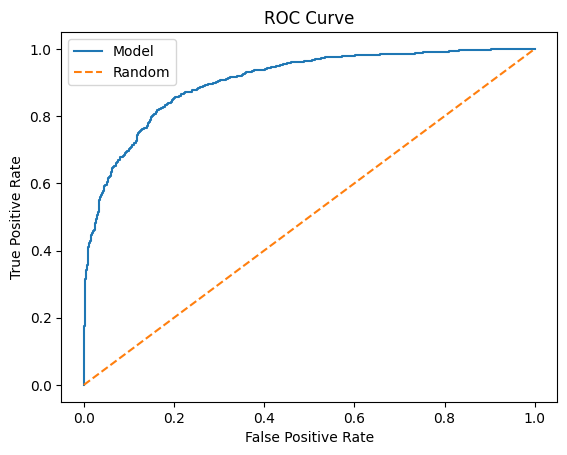

              precision    recall  f1-score   support

         0.0       0.74      0.90      0.82      1122
         1.0       0.88      0.70      0.78      1142

    accuracy                           0.80      2264
   macro avg       0.81      0.80      0.80      2264
weighted avg       0.81      0.80      0.80      2264



In [36]:
# --------------------------------------------------
# Additional evaluation diagnostics
# --------------------------------------------------
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

print("\nConfusion Matrix")
print(cm)

# Positive class rate
positive_rate = np.mean(all_labels)
print(f"\nPositive rate in test set: {positive_rate:.4f}")

# ROC curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)

plt.figure()
plt.plot(fpr, tpr, label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Classification report
print(classification_report(all_labels, all_preds))

In [34]:
# --------------------------------------------------
# Save predictions
# --------------------------------------------------

results = pd.DataFrame({
    "label": all_labels,
    "probability": all_probs,
    "prediction": all_preds
})

results.to_csv("test_predictions.csv", index=False)

In [35]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

         0.0       0.74      0.90      0.82      1122
         1.0       0.88      0.70      0.78      1142

    accuracy                           0.80      2264
   macro avg       0.81      0.80      0.80      2264
weighted avg       0.81      0.80      0.80      2264

